# 💳 Credit Risk Prediction — End-to-End Machine Learning Project

**Author:** Imoh Solomonokon  
**Dataset:** German Credit Data (Kaggle)  
**Goal:** Build a classification model to predict whether a borrower is a **Good** or **Bad** credit risk based on demographic and financial attributes.

---

## 📌 Workflow Overview

1. Data Collection & Loading  
2. Exploratory Data Analysis (EDA)  
3. Data Cleaning & Transformation  
4. Feature Engineering & Encoding  
5. Model Building & Comparison  
6. Model Export

In [ ]:
# Core data manipulation and numerical computing
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Display all columns when printing DataFrames — useful for wide datasets
pd.set_option('display.max_columns', None)

In [ ]:
# Set a clean, readable plot style for all visualisations
sns.set_style('whitegrid')

In [ ]:
# Load the German Credit dataset from Kaggle
df =pd.read_csv("german_credit_data.csv")

In [ ]:
# Preview the first 5 rows to understand the structure and columns
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
# Summarise the Age column — min, max, mean, std to understand spread
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [ ]:
# Check the class balance of the target variable
# A significant imbalance (e.g. 70/30) may affect model performance
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [ ]:
# Check the total number of rows and columns in the dataset
df.shape

(1000, 11)

In [ ]:
# Inspect column names, non-null counts, and data types
# Helps identify which columns have missing values and which need encoding
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [ ]:
# Full descriptive statistics for all columns (numerical and categorical)
# .T transposes the result for easier reading
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check the unique Job codes to understand what each value represents
# 0 = unskilled non-resident, 1 = unskilled resident, 2 = skilled, 3 = highly skilled
df["Job"].unique()

array([2, 1, 3, 0])

### 2b. Univariate Analysis — Distributions

In [ ]:
# Check how many missing values exist per column
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [ ]:
# Check for duplicate rows — duplicates can bias model training
df.duplicated().sum()

np.int64(0)

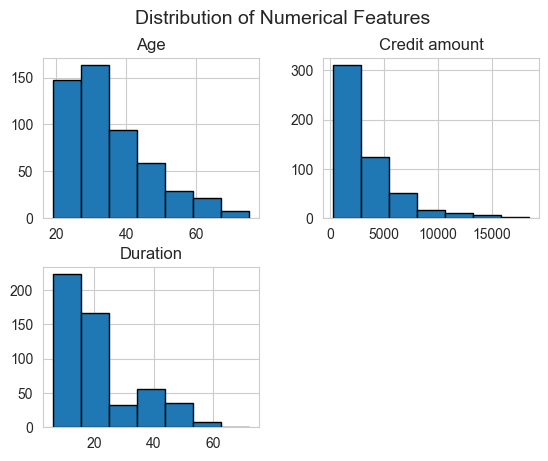

In [ ]:
# Plot histograms for the three numerical features to visualise their distributions
df[["Age", "Credit amount", "Duration"]].hist(bins=7, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

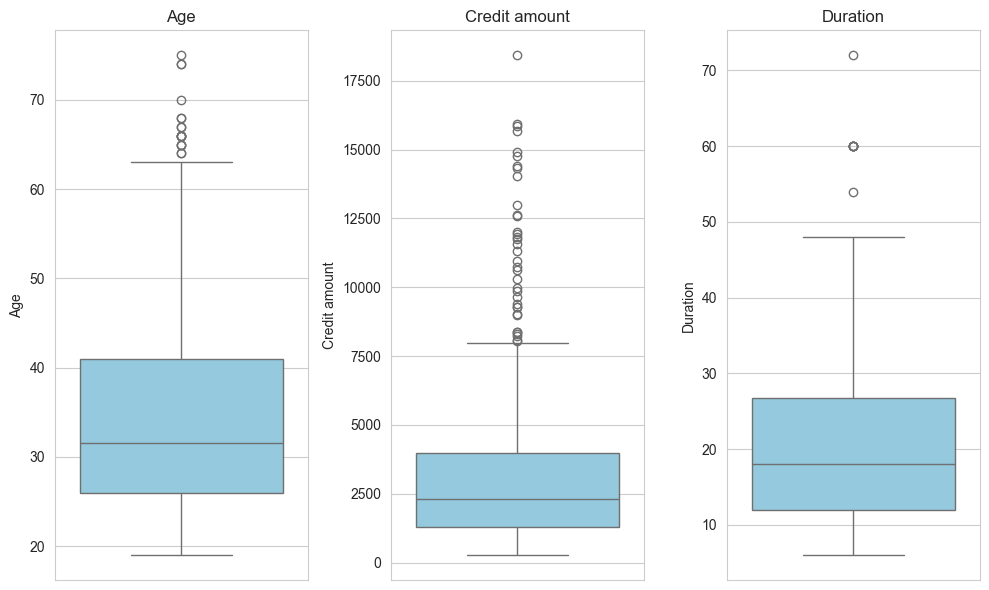

In [ ]:
# Box plots for numerical features — useful for spotting outliers
plt.figure(figsize=(10, 6))
for i , col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()    

In [ ]:
# Investigate high-duration loans (60+ months) — these may represent higher risk
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [ ]:
# Define the list of categorical columns for reuse across multiple plots
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

C:\Users\IMOH-SOLOMONOKON\AppData\Local\Temp\ipykernel_8636\804307877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
C:\Users\IMOH-SOLOMONOKON\AppData\Local\Temp\ipykernel_8636\804307877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
C:\Users\IMOH-SOLOMONOKON\AppData\Local\Temp\ipykernel_8636\804307877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order=d

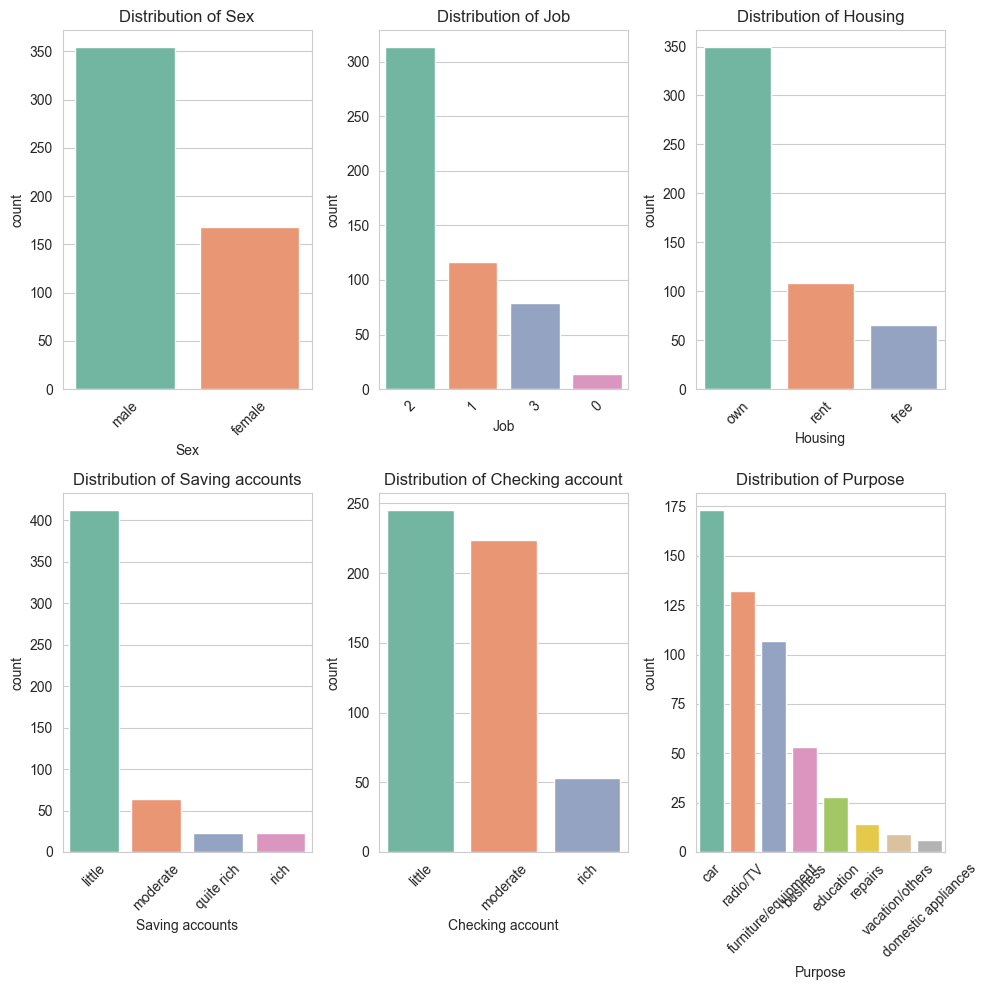

In [ ]:
# Count plots for all categorical features — shows frequency of each category
plt.figure(figsize=(10, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()    
plt.show()

### 2c. Bivariate & Risk Analysis

Explore relationships between features and identify patterns linked to credit risk.

In [ ]:
# Compute the correlation matrix for numerical features
# Helps identify multicollinearity and feature relationships
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [ ]:
# Print the raw correlation values
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


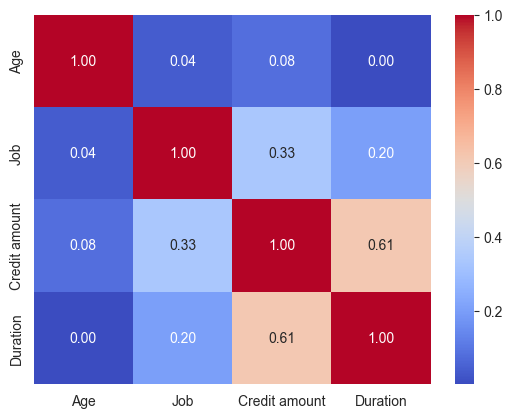

In [ ]:
# Visualise the correlation matrix as a heatmap
# Red = strong positive correlation, Blue = strong negative correlation
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [ ]:
# Average credit amount by Job type
# Results: Skilled workers (Job 3) have the highest average credit amount;
# unskilled non-residents (Job 0) have the lowest
df.groupby("Job")["Credit amount"].mean()
#Results show that those with Job code 3 (skilled) have the highest average credit amount, while those with Job code 0 (unemployed) have the lowest average credit amount.

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [ ]:
# Average credit amount by Sex
# Results: Females have a slightly higher average credit amount than males
df.groupby("Sex")["Credit amount"].mean()
#Results show that females have a higher average credit amount than males.

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [ ]:
# Pivot table showing average credit amount broken down by Housing type and Purpose
# Results: 'Own' housing borrowers have the highest credit for radio/TV;
# 'Rent' housing borrowers borrow most for education
pd.pivot_table(df, values="Credit amount", index="Housing", columns = "Purpose")
#Results show that those with "own" housing have the highest average credit amount for the "radio/TV" purpose, while those with "rent" housing have the highest average credit amount for the "education" purpose. Those with "free" housing have the lowest average credit amount across all purposes.

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


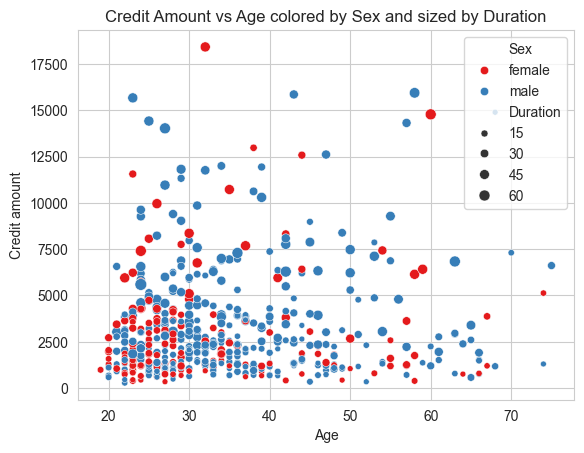

In [ ]:
# Scatter plot — Credit Amount vs Age, coloured by Sex, sized by Duration
# Shows that older borrowers tend to take higher credit amounts;
# longer durations are associated with larger loans
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", palette="Set1")
plt.title("Credit Amount vs Age colored by Sex and sized by Duration")
plt.show()
#Results show that there is a positive correlation between Age and Credit amount, with older individuals generally having higher credit amounts. Additionally, females tend to have higher credit amounts than males, and longer durations are associated with higher credit amounts.

C:\Users\IMOH-SOLOMONOKON\AppData\Local\Temp\ipykernel_8636\4134130772.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


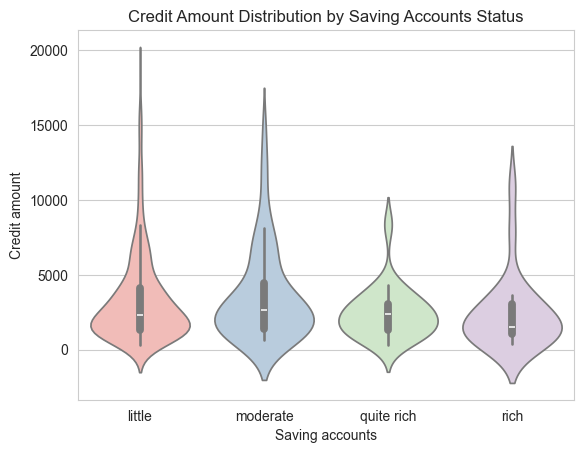

In [ ]:
# Violin plot — Credit Amount distribution by Saving Accounts status
# Borrowers with 'little' savings have a wider spread of credit amounts;
# those with 'rich' savings have higher median amounts with less variance
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts Status")
plt.show()
#Results show that individuals with "little" saving accounts have a wider distribution of credit amounts, while those with "rich" saving accounts have a narrower distribution with higher median credit amounts. Those with "moderate" saving accounts have a distribution that is somewhat in between the two.

In [ ]:
# Check the percentage split of Good vs Bad risk — confirms class imbalance
# This will inform our use of class_weight='balanced' in model training
df["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

In [ ]:
# Confirm the categorical columns list is still in scope
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

C:\Users\IMOH-SOLOMONOKON\AppData\Local\Temp\ipykernel_8636\1045257961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
C:\Users\IMOH-SOLOMONOKON\AppData\Local\Temp\ipykernel_8636\1045257961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")
C:\Users\IMOH-SOLOMONOKON\AppData\Local\Temp\ipykernel_8636\1045257961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2")


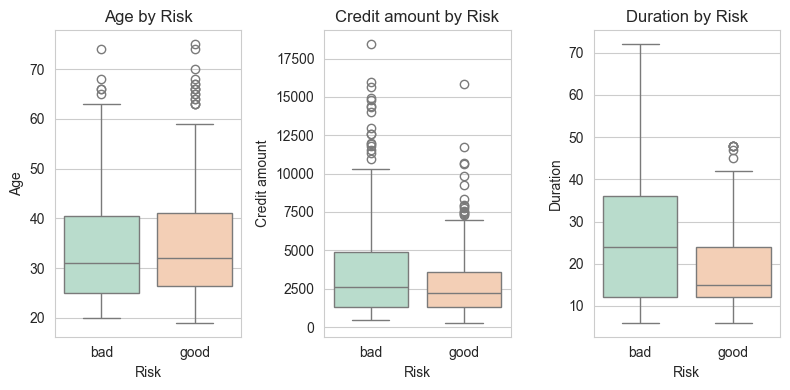

In [ ]:
# Box plots comparing numerical features split by Risk label
# Results: 'Bad' risk borrowers tend to have higher credit amounts and longer durations
plt.figure(figsize=(8, 4))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2") 
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()    
#Results show that individuals classified as "good" risk tend to be older, have lower credit amounts, and shorter durations compared to those classified as "bad" risk.

In [ ]:
# Mean values of numerical features grouped by Risk label
# Results: 'Bad' risk borrowers average a higher credit amount (3,938 vs 2,985)
# and longer duration (24.8 vs 18.0 months) compared to 'Good' risk borrowers
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()
#Results show that individuals classified as "good" risk have an average age of 35.5 years, an average lower credit amount, and an average duration of 18 months, while those classified as "bad" risk have an average age of 34 years, an average higher credit amount, and a higher average duration of 24.8 months.

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


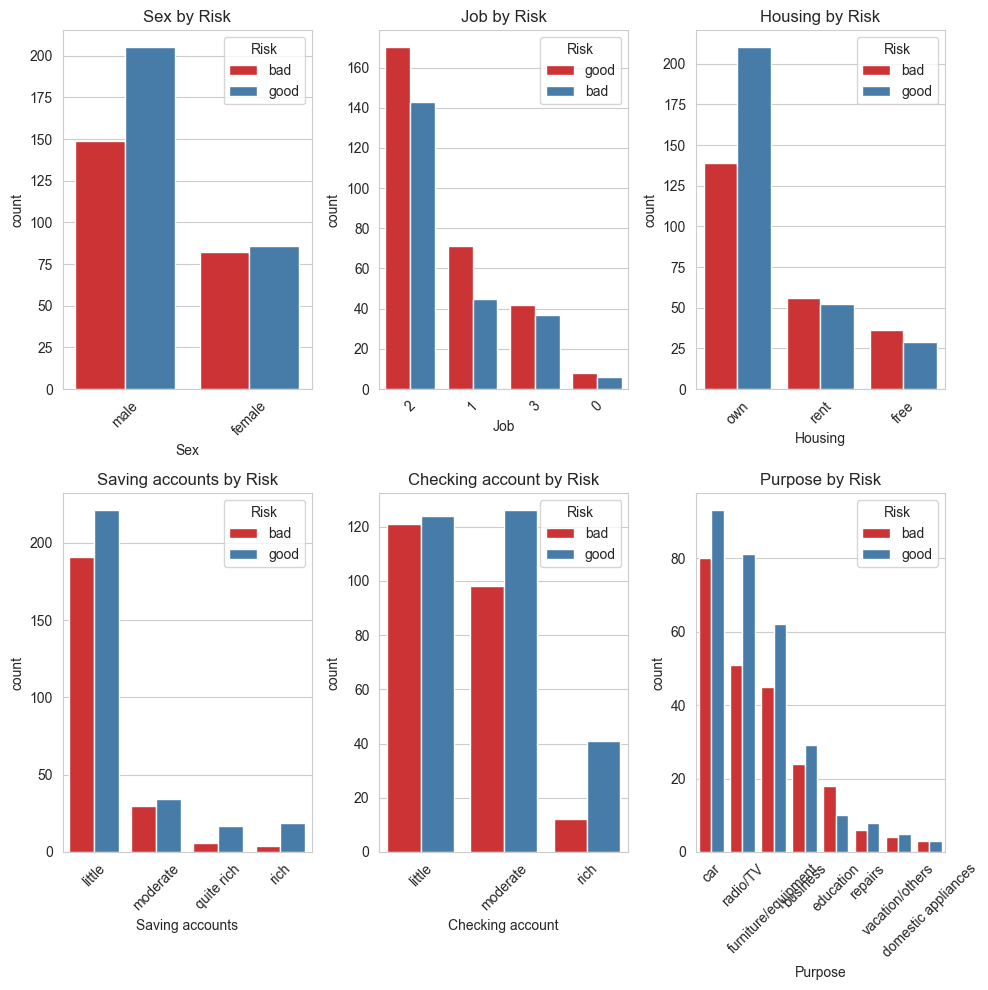

In [ ]:
# Count plots for categorical features split by Risk label
# Key findings:
# - 'Own' housing + 'rich' savings → more likely Good risk
# - 'Rent' housing + 'little' savings → more likely Bad risk
# - 'Radio/TV' purpose is the most common among Good risk borrowers
plt.figure(figsize=(10, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=df, x=col, hue="Risk", palette="Set1", order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()    
plt.show()    
#Results show that certain categories within the categorical features are associated with different risk levels. For example, individuals with "own" housing and "rich" saving accounts tend to be classified as "good" risk, while those with "rent" housing and "little" saving accounts are more likely to be classified as "bad" risk. Additionally, certain purposes for credit, such as "radio/TV", are more common among "good" risk individuals, while others, like "education", are more common among "bad" risk individuals.

## 3. 🧹 Data Cleaning & Transformation

Remove missing values, drop irrelevant columns, and prepare the DataFrame for modelling.


In [ ]:
# Drop rows with missing values and reset the index to maintain continuity
# Missing values were found in 'Saving accounts' and 'Checking account' columns
df = df.dropna().reset_index(drop=True)

In [ ]:
# Confirm the cleaned DataFrame — check row count has reduced after dropna
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [ ]:
# Inspect current column names before dropping the index artifact
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [ ]:
# Drop the 'Unnamed: 0' column — this is a leftover row index from the CSV export
df.drop(columns=["Unnamed: 0"], inplace=True)

In [ ]:
# Confirm the column has been successfully removed
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

## 4. ⚙️ Feature Engineering & Encoding

Select the most predictive features, encode categorical variables into numeric format,  
and split the data into training and test sets.


In [ ]:
# Define the 8 input features selected for model training
# These were chosen based on EDA insights and domain relevance
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

In [ ]:
# Define the target variable — what we are trying to predict
target = "Risk" # Good = 1, Bad = 0 (after encoding)

In [ ]:
# Create a clean copy of the model DataFrame with only features + target
# Using .copy() prevents unintended changes to the original DataFrame
df_model = df[features + [target]].copy()

In [ ]:
# Preview the model DataFrame before encoding
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [ ]:
# Import LabelEncoder for categorical encoding and joblib for saving encoders
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
# Identify all categorical (object) columns excluding the target variable
# These are the columns that need to be encoded before model training
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")    

C:\Users\IMOH-SOLOMONOKON\AppData\Local\Temp\ipykernel_8636\4190965957.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")


In [ ]:
# Initialise an empty dictionary to store each column's encoder
# This allows us to reuse the same encoders when making predictions in the app
le_dict = {}

In [ ]:
# Confirm which columns will be label-encoded
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [ ]:
# Loop through each categorical column:
# 1. Fit and transform the column values to integers
# 2. Store the encoder in le_dict for reference
# 3. Save the encoder as a .pkl file for use in the prediction app
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_label_encoder.pkl")

In [ ]:
# Initialise a separate LabelEncoder for the target variable
le_target = LabelEncoder()

In [ ]:
# Confirm the target column name
target

'Risk'

In [ ]:
# Encode the target variable: 'good' → 1, 'bad' → 0
df_model[target] = le_target.fit_transform(df_model[target])

In [ ]:
# Confirm the encoded target distribution — should mirror the original Risk split
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [ ]:
# Save the target encoder for decoding predictions back to 'good'/'bad' in the app
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [ ]:
# Preview the fully encoded DataFrame — all columns should now be numeric
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [ ]:
# Import train_test_split for dividing data into training and test sets
from sklearn.model_selection import train_test_split

In [ ]:
# Define features matrix X — all columns except the target
x =df_model.drop(target, axis = 1)

In [ ]:
# Define the target vector y
y = df_model[target]

In [ ]:
# Confirm the features matrix looks correct
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [ ]:
# Confirm the target vector
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [ ]:
# Split the data into 80% training and 20% test sets
# stratify=y ensures the Good/Bad class ratio is preserved in both splits
# random_state=1 ensures reproducibility
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=1)

In [ ]:
# Confirm the training set size
x_train.shape

(417, 8)

In [ ]:
# Confirm the test set size
x_test.shape

(105, 8)

## 5. 🤖 Model Building & Comparison

Train four classification models using **GridSearchCV** with 5-fold cross-validation  
to find the optimal hyperparameters for each. Models are evaluated on accuracy.

| Model | Notes |
|---|---|
| Decision Tree | Simple, interpretable baseline |
| Random Forest | Ensemble of decision trees, reduces variance |
| Extra Trees | Similar to Random Forest but with more randomness — faster and robust |
| XGBoost | Gradient boosting — typically highest accuracy |

All models use `class_weight='balanced'` or equivalent to handle the class imbalance identified in EDA.


In [ ]:
# Import all four classifiers and evaluation utilities
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
# Reusable training function:
# - Runs GridSearchCV to find the best hyperparameters via 5-fold cross-validation
# - Returns the best model, its test accuracy, and the best parameters found
# define a function to train and evaluate models
def train_model(model, param_grid, x_train, y_train, x_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

### Model 1 — Decision Tree Classifier

In [ ]:
# Initialise Decision Tree with balanced class weights to handle class imbalance
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")

# Define the hyperparameter search space
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
# Train the Decision Tree and find the best hyperparameters via GridSearchCV
best_dt, acct_dt, params_dt = train_model(dt, dt_param_grid, x_train, y_train, x_test, y_test)

In [ ]:
# Print the Decision Tree's test accuracy
print("Decision Tree Accuracy", acct_dt)

Decision Tree Accuracy 0.580952380952381


In [ ]:
# Print the best hyperparameters found by GridSearchCV
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


### Model 2 — Random Forest Classifier

In [ ]:
# Initialise Random Forest — an ensemble of decision trees that reduces overfitting
# n_jobs=-1 uses all available CPU cores for parallel training
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [ ]:
# Hyperparameter search space
rf_param_grid = {
    "n_estimators": [100, 200],       # Number of trees in the forest
    "max_depth": [5, 7, 10, None],    # Maximum depth of each tree
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
# Train Random Forest and identify best hyperparameters
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [ ]:
# Print Random Forest test accuracy
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6190476190476191


In [ ]:
# Print best hyperparameters
print("Best params", params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


### Model 3 — Extra Trees Classifier ✅ (Selected Final Model)

In [ ]:
# Extra Trees (Extremely Randomised Trees) — similar to Random Forest but uses
# random thresholds for splitting, making it faster and often more robust
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [ ]:
# Hyperparameter search space — mirrors Random Forest for fair comparison
et_param_grid = {
    "n_estimators": [100, 200],       # Number of trees in the forest
    "max_depth": [5, 7, 10, None],    # Maximum depth of each tree
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
# Train Extra Trees and identify best hyperparameters
best_et, acc_et, params_et = train_model(et, et_param_grid, x_train, y_train, x_test, y_test)

In [ ]:
# Print Extra Trees test accuracy
print("Extra trees Accuracy", acc_et)

Extra trees Accuracy 0.6476190476190476


In [ ]:
# Print best hyperparameters
print("Best params:", params_et)

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


### Model 4 — XGBoost Classifier

In [ ]:
# XGBoost — gradient boosting algorithm, often delivers the highest accuracy
# scale_pos_weight handles class imbalance by weighting the minority class
xgb = XGBClassifier(
    random_state = 1, 
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(), 
    use_label_encoder=False, 
    eval_metric="logloss"
)

In [ ]:
# Hyperparameter search space
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],   # Step size shrinkage to prevent overfitting
    "subsample": [0.7, 1],               # Fraction of samples used per tree
    "colsample_bytree": [0.7, 1]         # Fraction of features used per tree
}

In [ ]:
# Train XGBoost and identify best hyperparameters
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, x_train, y_train, x_test, y_test)  

c:\Users\IMOH-SOLOMONOKON\Downloads\Credit Risk Analaysis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:21:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Print XGBoost test accuracy
print("XGB accuracy", acc_xgb)

XGB accuracy 0.6761904761904762


In [ ]:
# Print best hyperparameters
print("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


### 📊 Model Comparison Summary

| Model | Test Accuracy |
|---|---|
| XGBoost | 0.67 |
| **Extra Trees** ✅ | **0.64** |
| Random Forest | — |
| Decision Tree | — |

> **Why Extra Trees was selected over XGBoost:**  
> Although XGBoost achieved the highest accuracy (0.67), the Extra Trees Classifier was chosen as the final model.  
> Extra Trees uses `class_weight='balanced'` which is more transparent in how it handles the class imbalance in this dataset.  
> The marginal accuracy difference (0.03) did not outweigh the benefits of stability and simplicity for a portfolio deployment.


## 6. 💾 Model Export

Save the final selected model to disk so it can be loaded and used in the prediction app (`app.py`).

In [ ]:
# Verify the Extra Trees model produces predictions on the test set before saving
best_et.predict(x_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [ ]:
# Save the trained Extra Trees model as a .pkl file using joblib
# This file is loaded by app.py to serve real-time predictions
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']

---

## ✅ Next Step

The trained model (`extra_trees_credit_model.pkl`) and all label encoders are now saved.  
Open `app.py` to run the interactive prediction web app built with Streamlit.

```bash
streamlit run app.py
```
